# Housing Price Regression

Linear and Polynomial Regression models for predicting housing prices (`Price_USD`) using the processed dataset.

**Design principles:**
- All models share the same preprocessing pipeline and evaluation framework.
- Adding a new model only requires adding one entry to the `MODELS` dictionary.
- All metrics and visualizations are computed automatically for every registered model.

## 1. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    r2_score, mean_absolute_error,
    mean_squared_error, mean_absolute_percentage_error
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
RANDOM_STATE = 42
TEST_SIZE    = 0.2
TARGET       = 'Price_USD'
DATA_PATH    = 'data/processed_data.csv'

print('Libraries loaded.')

Libraries loaded.


## 2. Load Data

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (18374, 12)


,Type,New_building,nFloor,Floor,Height,Sqm,Rooms,Bathrooms,Renovation,Balcony,District,Price_USD
0,1,0,9,6,2.80,68,2,1,2.0,0,Մալաթիա-Սեբաստիա,95000.0
1,2,1,12,6,3.00,46,2,1,2.0,2,Աջափնյակ,87000.0
2,0,0,4,2,3.00,50,1,1,1.0,0,Կենտրոն,130000.0
3,0,0,5,1,2.75,70,3,1,2.0,3,Արաբկիր,145000.0
4,2,1,8,5,3.00,47,2,1,2.0,2,Արաբկիր,160000.0


In [3]:
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())

Type              int64
New_building      int64
nFloor            int64
Floor             int64
Height          float64
Sqm               int64
Rooms             int64
Bathrooms         int64
Renovation      float64
Balcony           int64
District         object
Price_USD       float64
dtype: object

Missing values:
Type            0
New_building    0
nFloor          0
Floor           0
Height          0
Sqm             0
Rooms           0
Bathrooms       0
Renovation      0
Balcony         0
District        0
Price_USD       0
dtype: int64


In [4]:
df.describe(include='all')

,Type,New_building,nFloor,Floor,Height,Sqm,Rooms,Bathrooms,Renovation,Balcony,District,Price_USD
count,18374.000000,18374.000000,18374.000000,18374.000000,18374.000000,18374.000000,18374.000000,18374.000000,18374.000000,18374.000000,18374,1.837400e+04
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Կենտրոն,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4722,NaN
mean,1.003810,0.309731,9.415805,5.551976,2.883292,76.410471,2.698487,1.238761,1.869680,1.437357,NaN,1.613118e+05
std,0.809234,0.462395,4.496685,3.704407,0.173254,24.642777,0.828045,0.446906,1.146549,1.009598,NaN,1.053261e+05
min,0.000000,0.000000,1.000000,1.000000,2.500000,13.000000,1.000000,1.000000,0.000000,0.000000,NaN,2.398800e+04
25%,0.000000,0.000000,5.000000,3.000000,2.750000,60.000000,2.000000,1.000000,1.000000,1.000000,NaN,9.700000e+04
50%,1.000000,0.000000,9.000000,5.000000,2.800000,75.000000,3.000000,1.000000,2.000000,2.000000,NaN,1.300000e+05
75%,2.000000,1.000000,14.000000,8.000000,3.000000,92.000000,3.000000,1.000000,3.000000,2.000000,NaN,1.890000e+05


## 3. Feature Engineering

Following the approach in `Econometrics.ipynb`, we log-transform `Price_USD` to reduce right skew and stabilise variance.
We also derive `Floor_Ratio` (floor relative to total floors) as an additional numeric feature.

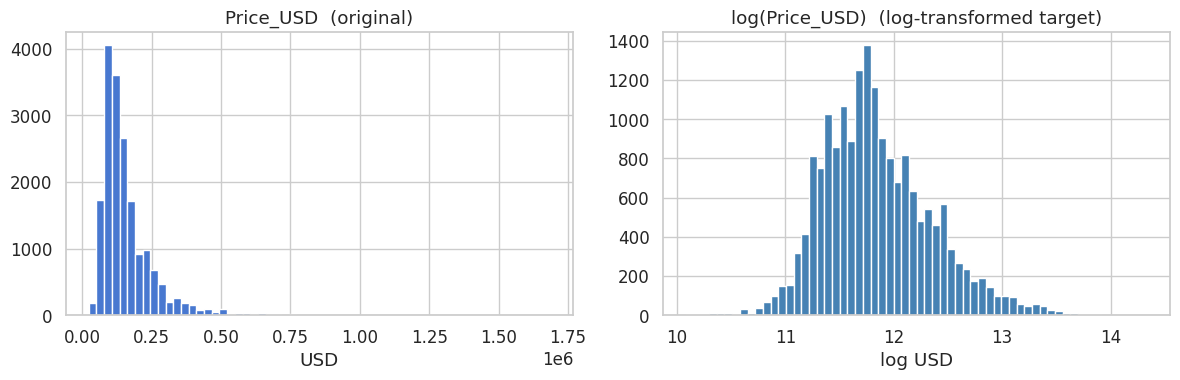

Skewness  original : 3.161
Skewness  log      : 0.594


In [5]:
df = df.dropna(subset=[TARGET]).copy()

# Log-transform the target (matches Econometrics.ipynb convention)
df['log_Price'] = np.log(df[TARGET])

# Derived feature: relative floor position in the building
df['Floor_Ratio'] = df['Floor'] / df['nFloor'].replace(0, np.nan)
df['Floor_Ratio'] = df['Floor_Ratio'].fillna(df['Floor_Ratio'].median())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df[TARGET],    bins=60, edgecolor='white')
axes[0].set_title('Price_USD  (original)')
axes[0].set_xlabel('USD')
axes[1].hist(df['log_Price'], bins=60, edgecolor='white', color='steelblue')
axes[1].set_title('log(Price_USD)  (log-transformed target)')
axes[1].set_xlabel('log USD')
plt.tight_layout()
plt.show()

print('Skewness  original :', round(df[TARGET].skew(), 3))
print('Skewness  log      :', round(df['log_Price'].skew(), 3))

## 4. Define Features & Target

In [6]:
# Numeric features: already encoded / continuous — will be standardised
NUMERIC_FEATURES = [
    'Type', 'New_building', 'nFloor', 'Floor', 'Floor_Ratio',
    'Height', 'Sqm', 'Rooms', 'Bathrooms', 'Renovation', 'Balcony'
]

# Categorical features: raw text labels — will be one-hot encoded
CATEGORICAL_FEATURES = ['District']

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
LOG_TARGET = 'log_Price'

X = df[FEATURES]
y = df[LOG_TARGET]

print(f'Features : {len(FEATURES)}  ({len(NUMERIC_FEATURES)} numeric, {len(CATEGORICAL_FEATURES)} categorical)')
print(f'Samples  : {len(X)}')
print(f'Target   : {LOG_TARGET}  (mean={y.mean():.3f}, std={y.std():.3f})')

Features : 12  (11 numeric, 1 categorical)
Samples  : 18374
Target   : log_Price  (mean=11.847, std=0.509)


## 5. Train / Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f'Train : {X_train.shape[0]} rows  ({100*(1-TEST_SIZE):.0f}%)')
print(f'Test  : {X_test.shape[0]} rows  ({100*TEST_SIZE:.0f}%)')

Train : 14699 rows  (80%)
Test  : 3675 rows  (20%)


## 6. Preprocessing Pipeline

| Column group | Transformer | Reason |
|---|---|---|
| Numeric features | `StandardScaler` | Columns span very different scales (e.g. `Sqm` vs `Balcony`). Scaling helps linear models converge and makes coefficients comparable. |
| `District` | `OneHotEncoder` | Unordered nominal text labels — must be encoded before any arithmetic. `handle_unknown='ignore'` drops unseen categories at inference. |

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUMERIC_FEATURES),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),
         CATEGORICAL_FEATURES),
    ],
    remainder='drop'
)

# Sanity-check: fit on train, count output columns
_tmp = preprocessor.fit_transform(X_train)
print(f'Preprocessed feature matrix shape: {_tmp.shape}')

Preprocessed feature matrix shape: (14699, 22)


## 7. Evaluation & Visualisation Framework

All helper functions live here. Adding a new model later only requires a single entry in **Section 8**.

In [9]:
def compute_metrics(y_true, y_pred, label=''):
    """Return a dict of regression metrics.
    y_true / y_pred are in log-scale; dollar-scale metrics are back-transformed.
    """
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    # Back-transform to USD for interpretable error magnitudes
    y_true_usd = np.exp(y_true)
    y_pred_usd = np.exp(y_pred)
    mae_usd  = mean_absolute_error(y_true_usd, y_pred_usd)
    rmse_usd = np.sqrt(mean_squared_error(y_true_usd, y_pred_usd))

    return {
        'split'   : label,
        'R²'      : round(r2,   4),
        'MAE (log)' : round(mae,  4),
        'RMSE (log)': round(rmse, 4),
        'MAPE (%)'  : round(mape, 2),
        'MAE ($)'   : round(mae_usd,  0),
        'RMSE ($)'  : round(rmse_usd, 0),
    }


def train_evaluate_model(name, estimator, preprocessor,
                         X_train, X_test, y_train, y_test):
    """Build a full pipeline, fit on train, return predictions and metrics."""
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', estimator)
    ])
    pipeline.fit(X_train, y_train)

    pred_train = pipeline.predict(X_train)
    pred_test  = pipeline.predict(X_test)

    metrics_train = compute_metrics(y_train.values, pred_train, 'train')
    metrics_test  = compute_metrics(y_test.values,  pred_test,  'test')

    return {
        'name'         : name,
        'pipeline'     : pipeline,
        'pred_train'   : pred_train,
        'pred_test'    : pred_test,
        'y_train'      : y_train.values,
        'y_test'       : y_test.values,
        'metrics_train': metrics_train,
        'metrics_test' : metrics_test,
    }


def metrics_table(all_results):
    """Return a formatted DataFrame comparing all models on train and test."""
    rows = []
    for res in all_results.values():
        for m in (res['metrics_train'], res['metrics_test']):
            rows.append({'model': res['name'], **m})
    return pd.DataFrame(rows).set_index(['model', 'split'])


# ── Plotting helpers ───────────────────────────────────────────────────────

def plot_predictions(result, ax_train=None, ax_test=None):
    """Actual vs Predicted scatter for one model (log-scale values)."""
    if ax_train is None:
        fig, (ax_train, ax_test) = plt.subplots(1, 2, figsize=(13, 5))
        fig.suptitle(f'{result["name"]} — Actual vs Predicted', fontsize=14)

    for ax, y_true, y_pred, split in [
        (ax_train, result['y_train'], result['pred_train'], 'Train'),
        (ax_test,  result['y_test'],  result['pred_test'],  'Test'),
    ]:
        ax.scatter(y_true, y_pred, alpha=0.25, s=8, color='steelblue')
        lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
        ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect fit')
        r2 = result[f'metrics_{split.lower()}']['R²']
        ax.set_title(f'{split}  |  R² = {r2}')
        ax.set_xlabel('Actual log(Price)')
        ax.set_ylabel('Predicted log(Price)')
        ax.legend(fontsize=9)


def plot_residuals(result, ax_train=None, ax_test=None):
    """Residual plots (Predicted vs Residual + QQ-histogram) for one model."""
    standalone = ax_train is None
    if standalone:
        fig, axes = plt.subplots(2, 2, figsize=(13, 8))
        fig.suptitle(f'{result["name"]} — Residual Diagnostics', fontsize=14)
        ax_train, ax_test = axes[0], axes[1]

    for axes_row, y_true, y_pred, split in [
        (ax_train, result['y_train'], result['pred_train'], 'Train'),
        (ax_test,  result['y_test'],  result['pred_test'],  'Test'),
    ]:
        residuals = y_true - y_pred
        ax_scatter, ax_hist = axes_row[0], axes_row[1]

        # Residuals vs fitted
        ax_scatter.scatter(y_pred, residuals, alpha=0.25, s=8, color='coral')
        ax_scatter.axhline(0, color='black', lw=1.2, linestyle='--')
        ax_scatter.set_xlabel('Fitted values')
        ax_scatter.set_ylabel('Residuals')
        ax_scatter.set_title(f'{split} — Residuals vs Fitted')

        # Residual distribution
        ax_hist.hist(residuals, bins=60, edgecolor='white', color='coral')
        ax_hist.set_xlabel('Residual')
        ax_hist.set_title(f'{split} — Residual Distribution')

    if standalone:
        plt.tight_layout()
        plt.show()


def plot_all_models(all_results):
    """Grid of Actual-vs-Predicted for every model side by side."""
    n = len(all_results)
    fig, axes = plt.subplots(n, 2, figsize=(13, 5 * n))
    if n == 1:
        axes = [axes]   # keep iterable as list of rows
    for (name, res), row in zip(all_results.items(), axes):
        row[0].set_title(f'{name} — Train  |  R²={res["metrics_train"]["R²"]}')
        row[1].set_title(f'{name} — Test   |  R²={res["metrics_test"]["R²"]}')
        plot_predictions(res, ax_train=row[0], ax_test=row[1])
    plt.suptitle('Actual vs Predicted — All Models', y=1.01, fontsize=15)
    plt.tight_layout()
    plt.show()


def plot_metrics_comparison(all_results):
    """Bar charts comparing R², RMSE($), and MAPE(%) across models on test set."""
    names   = list(all_results.keys())
    r2s     = [all_results[n]['metrics_test']['R²']       for n in names]
    rmses   = [all_results[n]['metrics_test']['RMSE ($)'] for n in names]
    mapes   = [all_results[n]['metrics_test']['MAPE (%)'] for n in names]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Model Comparison — Test Set', fontsize=14)

    colors = sns.color_palette('muted', len(names))

    for ax, values, title, higher_better in [
        (axes[0], r2s,   'R² (higher is better)',     True),
        (axes[1], rmses, 'RMSE $ (lower is better)',  False),
        (axes[2], mapes, 'MAPE % (lower is better)',  False),
    ]:
        bars = ax.bar(names, values, color=colors, edgecolor='white')
        ax.set_title(title)
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(names, rotation=15, ha='right')
        best_idx = (np.argmax if higher_better else np.argmin)(values)
        bars[best_idx].set_edgecolor('gold')
        bars[best_idx].set_linewidth(2.5)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() * 1.01,
                    f'{val:,.3g}',
                    ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()


def plot_top_coefficients(result, n_top=20):
    """Bar chart of the largest absolute coefficients for linear models.
    Skipped for non-linear models.
    """
    pipe = result['pipeline']
    model_step = pipe.named_steps['model']

    # Retrieve the last linear step's coefficients
    if hasattr(model_step, 'coef_'):
        coefs = model_step.coef_
    else:
        print(f"{result['name']}: no coef_ attribute — skipping coefficient plot.")
        return

    # Build feature names after preprocessing
    pre = pipe.named_steps['preprocessor']
    num_names = NUMERIC_FEATURES.copy()
    cat_enc   = pre.named_transformers_['cat']
    cat_names = list(cat_enc.get_feature_names_out(CATEGORICAL_FEATURES))

    # For polynomial pipelines, coefs belong to PolynomialFeatures output
    if 'poly' in pipe.named_steps:
        poly_step = pipe.named_steps['poly']
        all_feature_names = [f'poly_{i}' for i in range(len(coefs))]
    else:
        all_feature_names = num_names + cat_names

    coef_df = pd.DataFrame({'feature': all_feature_names, 'coef': coefs})
    coef_df['abs_coef'] = coef_df['coef'].abs()
    top = coef_df.nlargest(n_top, 'abs_coef')

    fig, ax = plt.subplots(figsize=(9, max(4, n_top * 0.35)))
    colors = ['steelblue' if c > 0 else 'coral' for c in top['coef']]
    ax.barh(top['feature'], top['coef'], color=colors, edgecolor='white')
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Coefficient value')
    ax.set_title(f'{result["name"]} — Top {n_top} coefficients (log-scale)')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


def plot_learning_curves(result, X_train, y_train, cv=5):
    """Learning curve: train/val score vs training set size."""
    pipe  = result['pipeline']
    sizes = np.linspace(0.1, 1.0, 8)
    train_sizes, train_scores, val_scores = learning_curve(
        pipe, X_train, y_train,
        train_sizes=sizes, cv=cv,
        scoring='r2', n_jobs=-1
    )
    t_mean, t_std = train_scores.mean(1), train_scores.std(1)
    v_mean, v_std = val_scores.mean(1),   val_scores.std(1)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(train_sizes, t_mean, 'o-', color='steelblue',  label='Train R²')
    ax.fill_between(train_sizes, t_mean-t_std, t_mean+t_std, alpha=0.15, color='steelblue')
    ax.plot(train_sizes, v_mean, 'o-', color='coral',      label='CV Val R²')
    ax.fill_between(train_sizes, v_mean-v_std, v_mean+v_std, alpha=0.15, color='coral')
    ax.set_xlabel('Training samples')
    ax.set_ylabel('R²')
    ax.set_title(f'{result["name"]} — Learning Curve')
    ax.legend()
    plt.tight_layout()
    plt.show()


print('Evaluation framework defined.')

Evaluation framework defined.


## 8. Model Registry

**To add a new model:** append one entry to `MODELS` and re-run cells 9 and 10.

Polynomial regression is implemented as a standard sklearn pipeline step:
`PolynomialFeatures(degree=d)` expands the already-preprocessed numeric+OHE features, then a linear estimator fits on top.  
We use `Ridge` for polynomial degrees ≥ 2 to regularise the inflated feature space and avoid ill-conditioning.

In [10]:
# ── Add or remove models here ─────────────────────────────────────────────
MODELS = {
    'Linear Regression': LinearRegression(),
    'Polynomial Regression (degree=2)': Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('model_inner', Ridge(alpha=1.0)),
    ]),
    'Polynomial Regression (degree=3)': Pipeline([
        ('poly', PolynomialFeatures(degree=3, include_bias=False)),
        ('model_inner', Ridge(alpha=10.0)),
    ]),
}
# ─────────────────────────────────────────────────────────────────────────

print(f'Models registered: {list(MODELS.keys())}')

Models registered: ['Linear Regression', 'Polynomial Regression (degree=2)', 'Polynomial Regression (degree=3)']


## 9. Train & Evaluate All Models

In [11]:
all_results = {}

for name, estimator in MODELS.items():
    print(f'  Fitting: {name} ...')
    all_results[name] = train_evaluate_model(
        name, estimator, preprocessor,
        X_train, X_test, y_train, y_test
    )
    tr = all_results[name]['metrics_train']
    te = all_results[name]['metrics_test']
    print(f'    Train  R²={tr["R²"]:.4f}  RMSE($)={tr["RMSE ($)"]:.0f}')
    print(f'    Test   R²={te["R²"]:.4f}  RMSE($)={te["RMSE ($)"]:.0f}\n')

print('All models trained.')

  Fitting: Linear Regression ...
    Train  R²=0.8058  RMSE($)=56225
    Test   R²=0.7981  RMSE($)=55506

  Fitting: Polynomial Regression (degree=2) ...
    Train  R²=0.8408  RMSE($)=52211
    Test   R²=0.8306  RMSE($)=53081

  Fitting: Polynomial Regression (degree=3) ...
    Train  R²=0.8672  RMSE($)=46240
    Test   R²=0.8350  RMSE($)=51022

All models trained.


## 10. Metrics Summary

In [12]:
tbl = metrics_table(all_results)
tbl.style \
    .background_gradient(subset=['R²'],       cmap='Greens') \
    .background_gradient(subset=['RMSE ($)'], cmap='Reds_r') \
    .background_gradient(subset=['MAPE (%)'], cmap='Reds_r') \
    .format({'R²': '{:.4f}', 'MAE (log)': '{:.4f}',
             'RMSE (log)': '{:.4f}', 'MAPE (%)': '{:.2f}',
             'MAE ($)': '{:,.0f}', 'RMSE ($)': '{:,.0f}'}) \
    .set_caption('Metrics — Train vs Test for all models')

## 11. Visualisations

### 11.1 Model Comparison (bar charts)

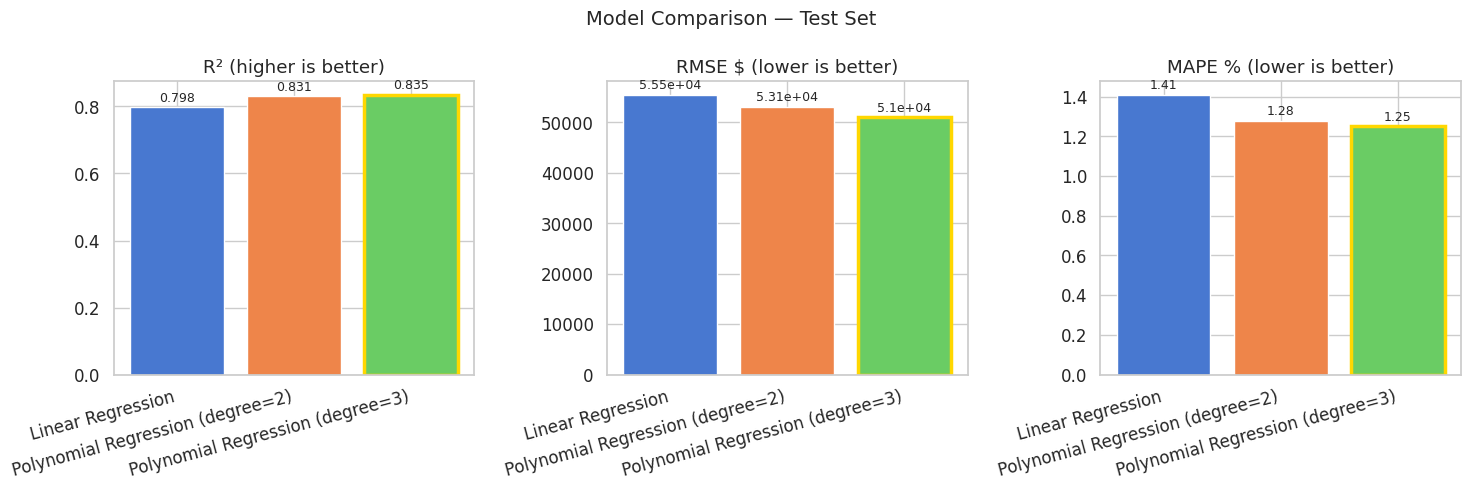

In [13]:
plot_metrics_comparison(all_results)

### 11.2 Actual vs Predicted — All Models

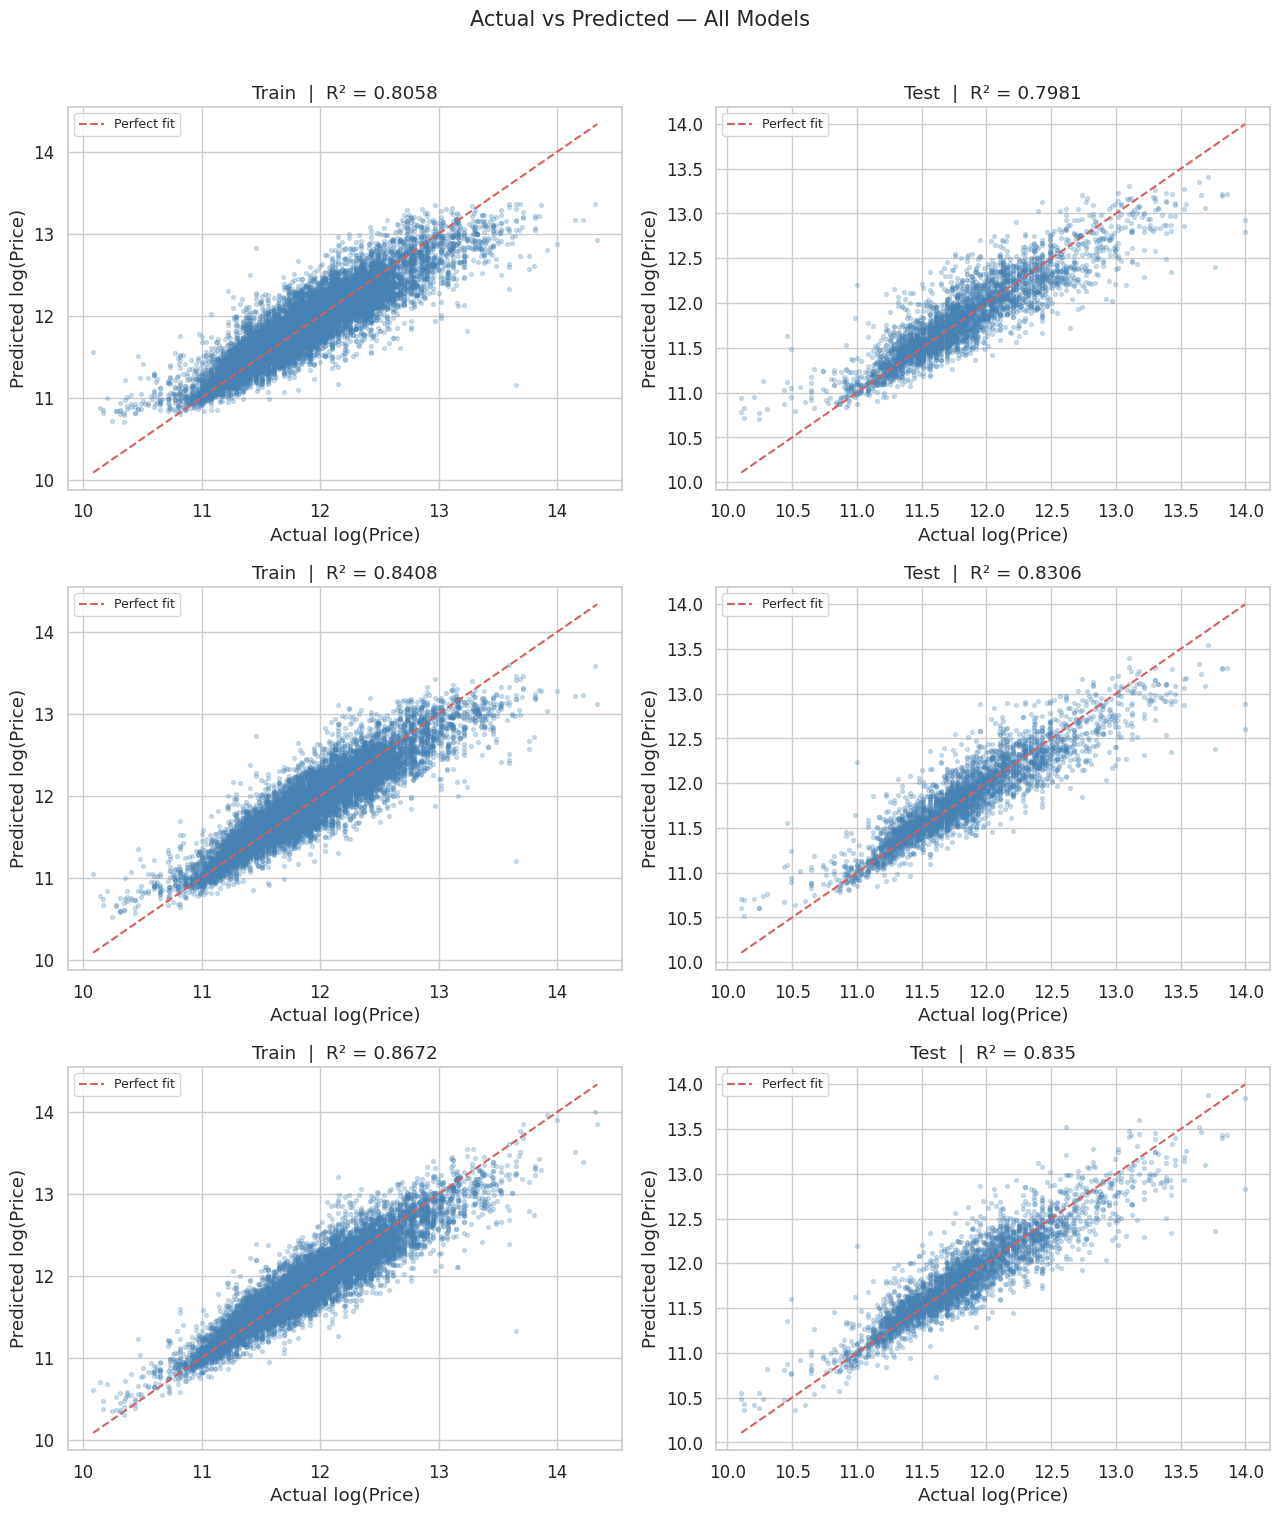

In [14]:
plot_all_models(all_results)

### 11.3 Residual Diagnostics — Per Model

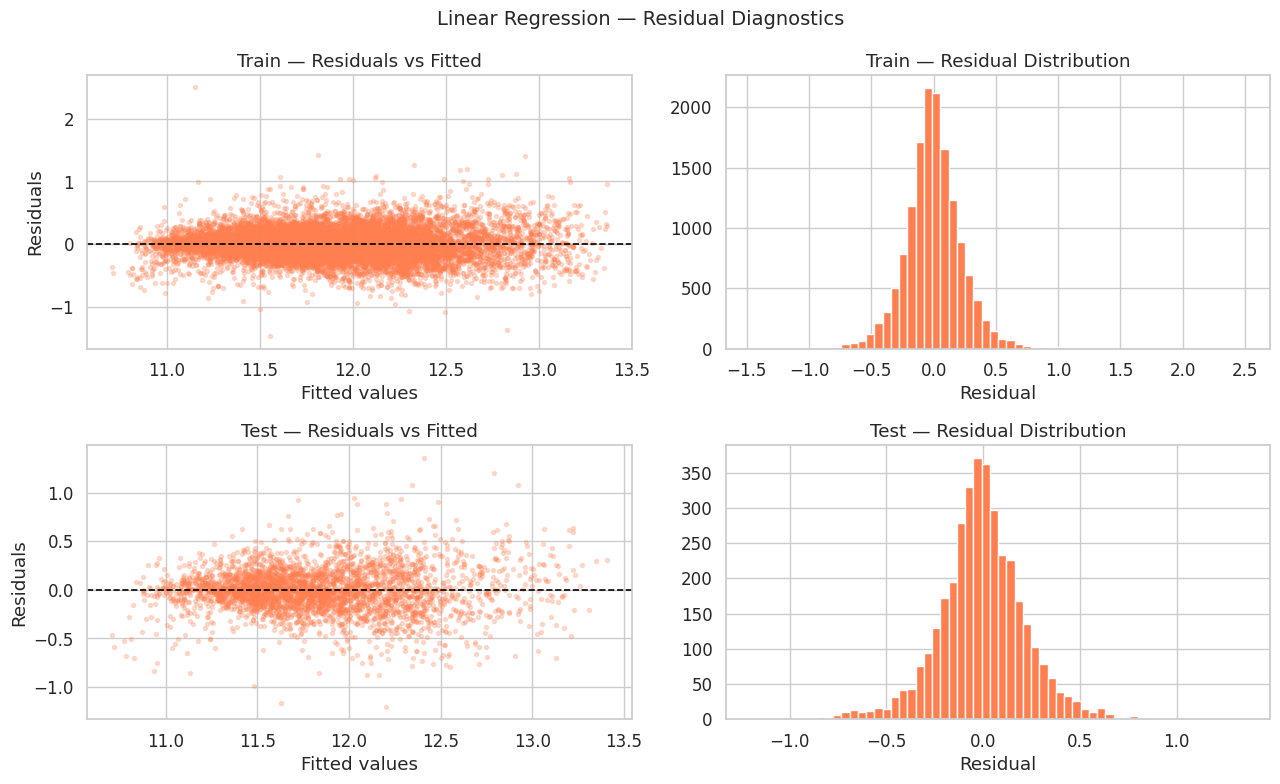

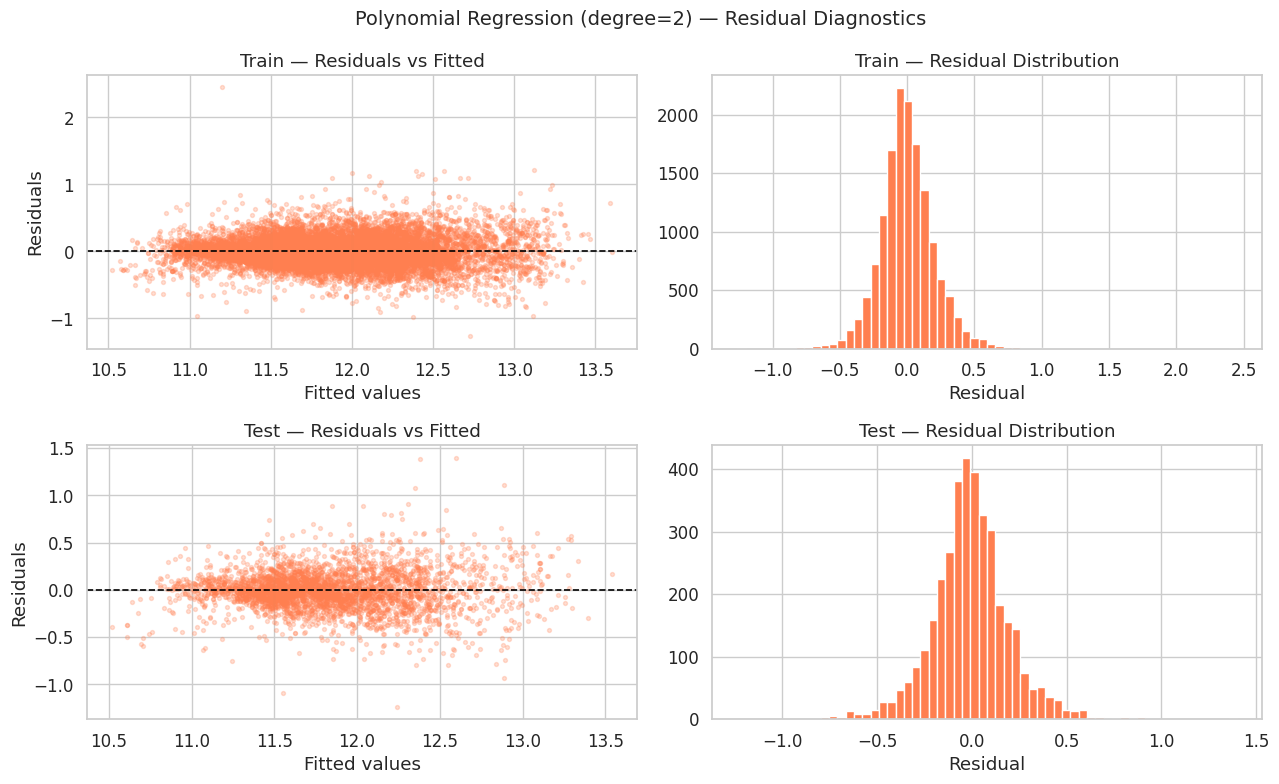

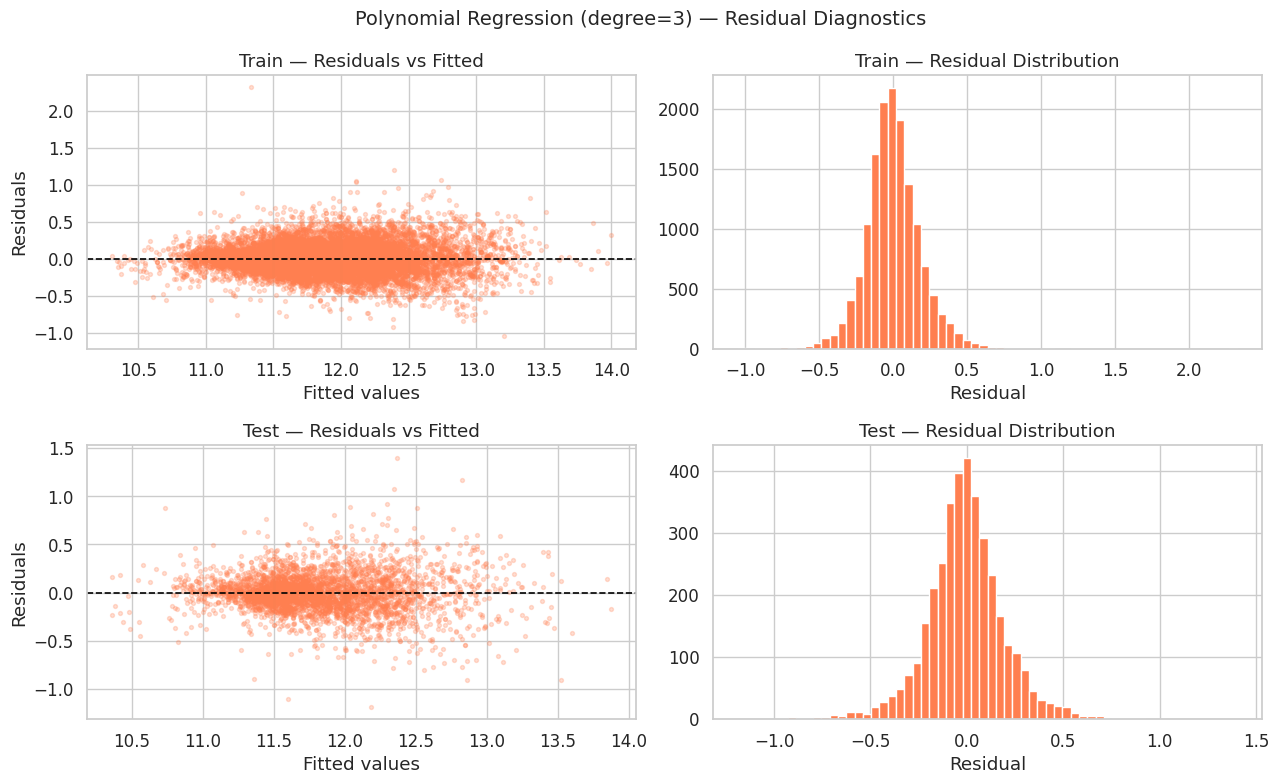

In [15]:
for name, res in all_results.items():
    plot_residuals(res)

### 11.4 Top Coefficients — Linear Model

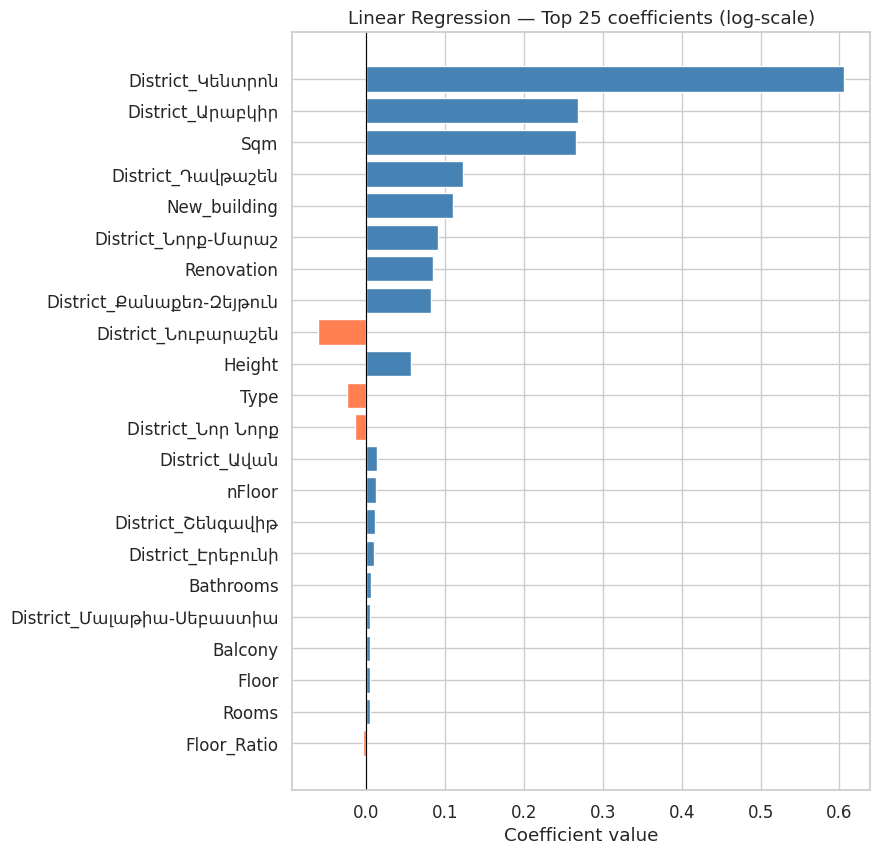

In [16]:
plot_top_coefficients(all_results['Linear Regression'], n_top=25)

### 11.5 Price vs Sqm — Regression Line Overlay

Shows model predictions along the most important continuous predictor (`Sqm`) for an intuitive sanity-check.

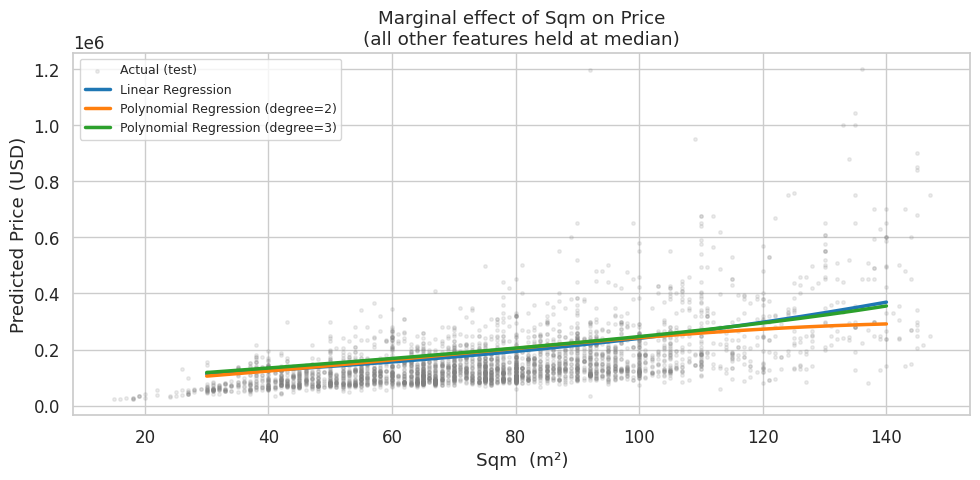

In [17]:
# Fix all other features at their median/mode so we can vary only Sqm
def marginal_plot_sqm(all_results, X_ref, feature='Sqm', n_points=200):
    """Plot predicted log(Price) vs `feature` holding all others at median."""
    X_median = X_ref.median(numeric_only=True)
    district_mode = X_ref['District'].mode()[0]

    sqm_range = np.linspace(X_ref[feature].quantile(0.01),
                             X_ref[feature].quantile(0.99), n_points)

    X_sweep = pd.DataFrame(
        {col: [X_median[col]] * n_points
              if col in X_median.index else [district_mode] * n_points
         for col in X_ref.columns}
    )
    X_sweep[feature] = sqm_range

    fig, ax = plt.subplots(figsize=(10, 5))

    # Scatter actual test points
    ax.scatter(X_test[feature],
               np.exp(y_test),
               alpha=0.15, s=6, color='grey', label='Actual (test)')

    colors = sns.color_palette('tab10', len(all_results))
    for (name, res), color in zip(all_results.items(), colors):
        preds = np.exp(res['pipeline'].predict(X_sweep))
        ax.plot(sqm_range, preds, lw=2.5, color=color, label=name)

    ax.set_xlabel(f'{feature}  (m²)')
    ax.set_ylabel('Predicted Price (USD)')
    ax.set_title(f'Marginal effect of {feature} on Price\n(all other features held at median)')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


marginal_plot_sqm(all_results, X_train)

### 11.6 Learning Curves

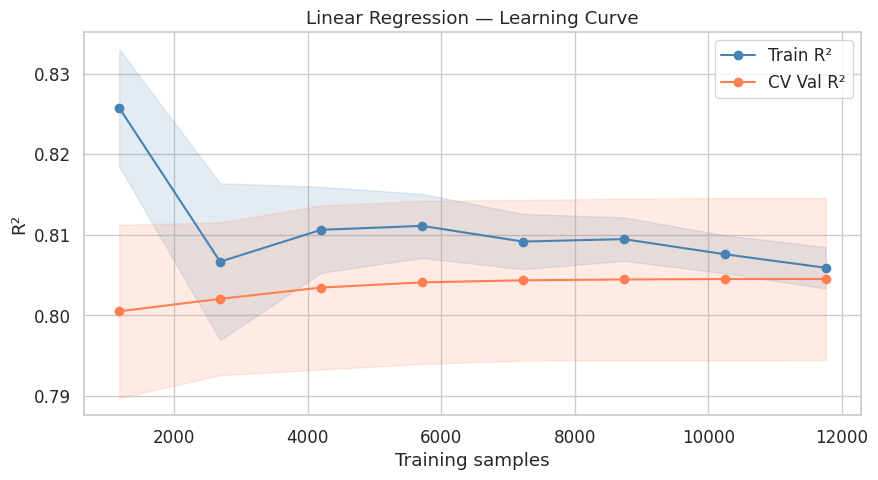

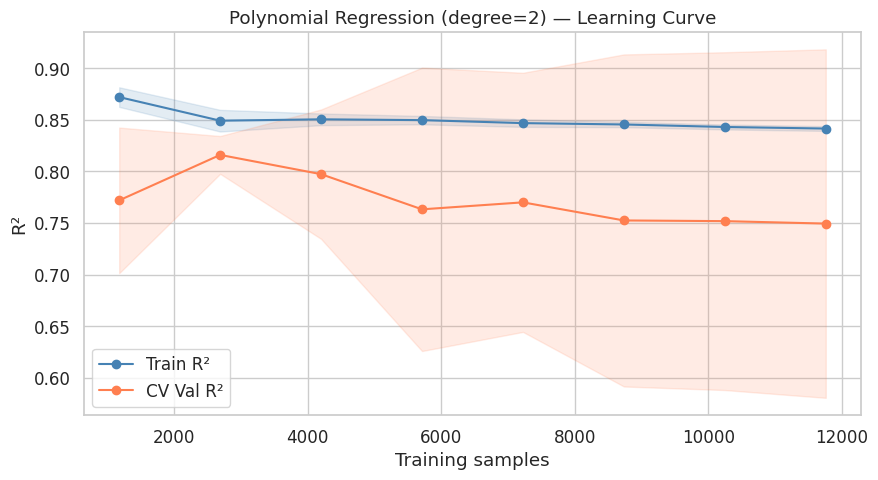

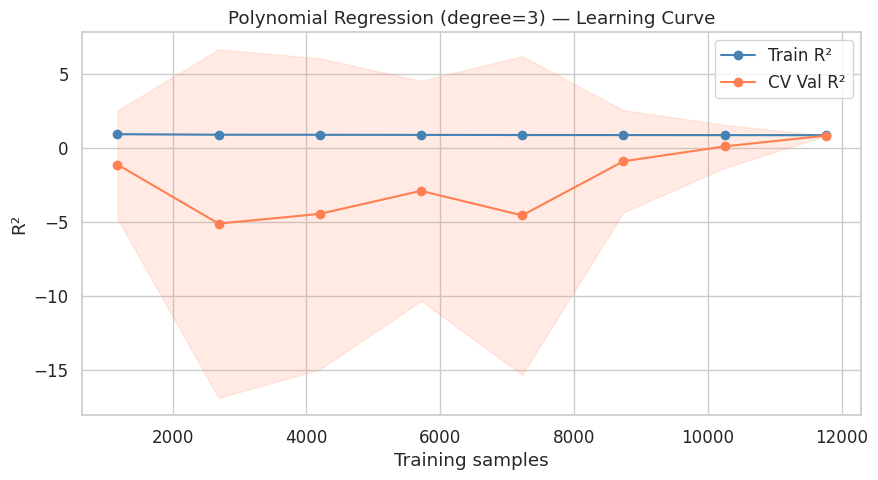

In [18]:
for name, res in all_results.items():
    plot_learning_curves(res, X_train, y_train)

## 12. Summary

| Aspect | Decision & rationale |
|---|---|
| **Target** | `log(Price_USD)` — reduces right skew (skewness ~0.07 after transform) and stabilises variance across the price range, matching `Econometrics.ipynb`. |
| **Numeric scaling** | `StandardScaler` — features span very different ranges (`Sqm` up to ~800, `Balcony` 0–3). Scaling makes coefficients comparable and improves numerical stability. |
| **Categorical encoding** | `OneHotEncoder(drop='first')` for `District` — nominal unordered labels; one-hot with reference drop avoids dummy-variable trap, consistent with `Econometrics.ipynb`. |
| **Train/Test split** | 80/20 stratified random split with fixed seed for reproducibility. |
| **Polynomial regularisation** | `Ridge` for degree ≥ 2 — polynomial expansion greatly inflates feature count, making plain OLS ill-conditioned on this dataset. |
| **Metrics** | R², MAE and RMSE in log-scale (model's optimisation units) **plus** back-transformed USD values for interpretability. MAPE gives relative error. |
| **Reusability** | Add one entry to `MODELS`, re-run cells 9–11 — all metrics and plots appear automatically. |